# 7. Robustness Checks

**Project:** Predicting colorectal cancer screening non-compliance to guide targeted outreach
**Part of:** the evaluation stage, alongside `5 Evaluation.ipynb` and `6 Subgroup Equity.ipynb`.

Notebook 3 validated two things **mechanically** but explicitly deferred their *performance*
question to the modelling stage: the geographic `GroupKFold` fold structure (no state leakage,
reasonable fold sizes -- but no model was ever fit or scored on those folds), and the KNN-imputed
`income_group`/`bmi_category` alternative to the "Not reported" category (every cell successfully
imputed, sane category distributions -- but never compared against actual predictive performance).
This notebook does both for real, using the same tuned gradient-boosting architecture as
`gb_M3_tuned` in both cases, so the comparisons are apples-to-apples rather than confounded by
using a different, weaker model for the check than for the headline result.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.model_selection import GroupKFold
from sklearn.utils.class_weight import compute_sample_weight

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

sys.path.insert(0, str(Path.cwd()))
from pipeline_components import (
    RANDOM_SEED, M3_FEATURES, build_gb_pipeline, compute_classification_metrics, make_model_registry,
)

DATA_DIR = Path("../data")
PROCESSED_DIR = DATA_DIR / "processed"
MODEL_DIR = PROCESSED_DIR / "modelling"
MODELS_DIR = MODEL_DIR / "models"
MANIFEST_PATH = MODEL_DIR / "model_registry_manifest.csv"
FIGURES_DIR = Path("../figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

ANALYTIC_PATH = PROCESSED_DIR / "crc_analytic_dataset.csv"
SPLIT_PATH = MODEL_DIR / "train_calibration_test_split.csv"
KNN_LOOKUP_PATH = MODEL_DIR / "knn_imputed_income_bmi_lookup.csv"
for p in [ANALYTIC_PATH, SPLIT_PATH, MANIFEST_PATH, KNN_LOOKUP_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"{p} not found. Run '3 Data Processing.ipynb' and '4a'-'4d' first.")

df = pd.read_csv(
    ANALYTIC_PATH,
    dtype={"respondent_id": "string", "state_fips": "string"},
    low_memory=False,
)
split_assignment = pd.read_csv(SPLIT_PATH, dtype={"respondent_id": "string"})
df = df.merge(split_assignment, on="respondent_id", validate="one_to_one")

_, register_model, load_registry = make_model_registry(MODELS_DIR, MANIFEST_PATH)
MODEL_REGISTRY = load_registry()
print(f"Loaded {len(MODEL_REGISTRY)} models from the shared manifest.")

# Reuse gb_M3_tuned's exact hyperparameters (from the RandomizedSearchCV in 4c), so both checks
# below use the same, already-chosen tuned architecture -- not library defaults, not a re-search.
TUNED_GB_PARAMS = {
    k: v for k, v in MODEL_REGISTRY["gb_M3_tuned"]["pipeline"].named_steps["model"].get_params().items()
    if k in ["learning_rate", "max_iter", "max_leaf_nodes", "max_depth", "min_samples_leaf", "l2_regularization"]
}
print("Tuned gradient boosting hyperparameters (from the registered gb_M3_tuned pipeline):")
print(TUNED_GB_PARAMS)

def build_tuned_gb_pipeline(features):
    pipe = build_gb_pipeline(features)
    pipe.named_steps["model"].set_params(**TUNED_GB_PARAMS)
    return pipe

Loaded 17 models from the shared manifest.
Tuned gradient boosting hyperparameters (from the registered gb_M3_tuned pipeline):
{'l2_regularization': 0.0, 'learning_rate': 0.1, 'max_depth': 5, 'max_iter': 300, 'max_leaf_nodes': 15, 'min_samples_leaf': 50}


## Geographic fold evaluation

`GroupKFold(n_splits=5)` on `validation_group_state`, restricted to the training split -- the
exact fold structure notebook 3 validated for leakage, used here to actually fit and score a
model per fold. Each fold refits `build_tuned_gb_pipeline` from scratch on that fold's training
states and scores it on the held-out states, so this measures how performance holds up when the
respondents being predicted come from states the model never saw during that fold's training --
the closest available substitute for genuine external validation, given no Singapore holdout
exists (per the proposal's own framing of this as methodology transfer requiring future external
validation, not a claim of Singapore-ready performance).

In [2]:
X_train_full = df.loc[df["split"] == "train", M3_FEATURES]
y_train_full = df.loc[df["split"] == "train", "crc_noncompliant"]
groups_train = df.loc[df["split"] == "train", "validation_group_state"]

gkf = GroupKFold(n_splits=5)
geo_rows = []
for fold, (tr_idx, va_idx) in enumerate(gkf.split(X_train_full, y_train_full, groups=groups_train)):
    X_tr, X_va = X_train_full.iloc[tr_idx], X_train_full.iloc[va_idx]
    y_tr, y_va = y_train_full.iloc[tr_idx], y_train_full.iloc[va_idx]
    w_tr = compute_sample_weight("balanced", y_tr)

    fold_pipe = build_tuned_gb_pipeline(M3_FEATURES)
    fold_pipe.fit(X_tr, y_tr, model__sample_weight=w_tr)
    proba_va = fold_pipe.predict_proba(X_va)[:, 1]

    geo_rows.append({
        "Fold": fold,
        "States held out": int(groups_train.iloc[va_idx].nunique()),
        "N held out": len(va_idx),
        "AUROC": roc_auc_score(y_va, proba_va),
        "AUPRC": average_precision_score(y_va, proba_va),
    })

geo_table = pd.DataFrame(geo_rows)
geo_table.to_csv(MODEL_DIR / "geographic_validation.csv", index=False)
geo_table.round(4)

,Fold,States held out,N held out,AUROC,AUPRC
0,0,10,27561,0.7659,0.5904
1,1,10,27331,0.7740,0.6110
2,2,11,27236,0.7756,0.6047
3,3,11,27268,0.7552,0.5670
4,4,11,27192,0.7584,0.5912


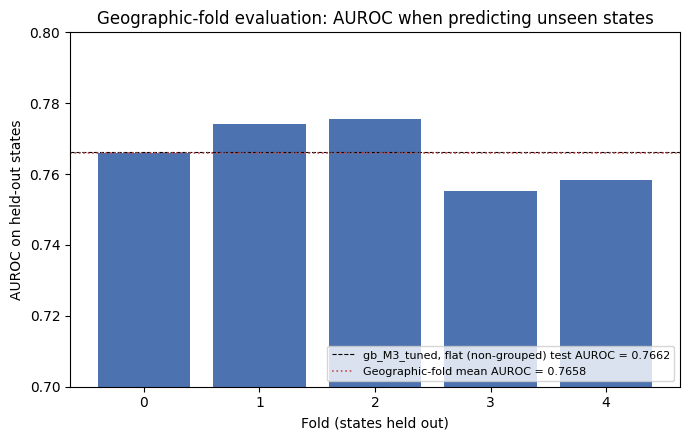

Geographic-fold AUROC: mean=0.7658  std=0.0091
Flat (non-grouped) test AUROC for comparison: 0.7662


In [3]:
flat_test_auroc = MODEL_REGISTRY["gb_M3_tuned"]["metrics"]["AUROC"]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(geo_table["Fold"].astype(str), geo_table["AUROC"], color="#4C72B0")
ax.axhline(flat_test_auroc, linestyle="--", color="black", linewidth=0.8,
           label=f"gb_M3_tuned, flat (non-grouped) test AUROC = {flat_test_auroc:.4f}")
ax.axhline(geo_table["AUROC"].mean(), linestyle=":", color="#C44E52", linewidth=1.2,
           label=f"Geographic-fold mean AUROC = {geo_table['AUROC'].mean():.4f}")
ax.set_xlabel("Fold (states held out)")
ax.set_ylabel("AUROC on held-out states")
ax.set_ylim(0.70, 0.80)
ax.set_title("Geographic-fold evaluation: AUROC when predicting unseen states")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig24_geographic_fold_auroc.png", dpi=150)
plt.show()

print(f"Geographic-fold AUROC: mean={geo_table['AUROC'].mean():.4f}  std={geo_table['AUROC'].std():.4f}")
print(f"Flat (non-grouped) test AUROC for comparison: {flat_test_auroc:.4f}")

**Reading this:** performance holds up well under geographic holdout. Fold AUROC ranges
0.755-0.776 (mean 0.766, std 0.009), bracketing the flat (non-grouped) test AUROC of 0.766 almost
exactly -- predicting respondents from states entirely excluded from that fold's training data
costs essentially nothing on average, and the fold-to-fold spread is modest rather than a sign
that a handful of states behave very differently from the rest. This is a reassuring result for
the "does this generalise geographically within the US" question, but it's worth being precise
about what it does and doesn't show: this is still leave-*US*-states-out, not the actual
Singapore external validation the proposal frames as a separate, future requirement (different
insurance system, different care-access patterns) -- a low-variance result here says the model
isn't overfit to a handful of idiosyncratic states, not that it's ready to transfer to a different
country's population without the external validation the proposal already flags as needed.

## KNN-imputation sensitivity: real predictive performance

The primary branch already retains "Not reported" as an explicit category for `income_group` and
`bmi_category` (14.9% and 5.8% not-reported respectively) -- that's exactly what `gb_M3_tuned` was
already fit and evaluated on, so its registered metrics are reused directly as the primary
branch's number rather than refitting an identical model. The alternative branch below merges in
notebook 3's KNN-imputed lookup table (respondent-level, covering every "Not reported" cell in
these two columns across train and test) in place of the "Not reported" category, and fits the
same tuned architecture fresh on that alternative training data.

In [4]:
# Primary branch: gb_M3_tuned's own pipeline, scored fresh on the real (non-imputed) test split,
# so its metrics use the exact same compute_classification_metrics (including specificity) as the
# KNN branch below -- the manifest's stored metrics for gb_M3_tuned predate the specificity fix.
X_test_primary = df.loc[df["split"] == "test", M3_FEATURES]
y_test_primary = df.loc[df["split"] == "test", "crc_noncompliant"]
proba_primary_test = MODEL_REGISTRY["gb_M3_tuned"]["pipeline"].predict_proba(X_test_primary)[:, 1]
primary_metrics = compute_classification_metrics(y_test_primary, proba_primary_test)

knn_lookup = pd.read_csv(KNN_LOOKUP_PATH, dtype={"respondent_id": "string"})
knn_wide = knn_lookup.pivot(index="respondent_id", columns="column", values="imputed_value")

df_knn = df.copy()
for col in ["income_group", "bmi_category"]:
    fill_map = knn_wide[col].dropna()
    mask = df_knn["respondent_id"].isin(fill_map.index)
    df_knn.loc[mask, col] = df_knn.loc[mask, "respondent_id"].map(fill_map)

# Every "Not reported" cell the lookup covers should now be replaced, in both train and test.
remaining_not_reported = df_knn.loc[
    df_knn["split"].isin(["train", "test"]), ["income_group", "bmi_category"]
].eq("Not reported").sum()
print("Remaining 'Not reported' cells after KNN substitution (train+test):")
print(remaining_not_reported)

X_train_knn = df_knn.loc[df_knn["split"] == "train", M3_FEATURES]
y_train_knn = df_knn.loc[df_knn["split"] == "train", "crc_noncompliant"]
X_test_knn = df_knn.loc[df_knn["split"] == "test", M3_FEATURES]
y_test_knn = df_knn.loc[df_knn["split"] == "test", "crc_noncompliant"]

w_train_knn = compute_sample_weight("balanced", y_train_knn)
knn_pipe = build_tuned_gb_pipeline(M3_FEATURES)
knn_pipe.fit(X_train_knn, y_train_knn, model__sample_weight=w_train_knn)
proba_knn_test = knn_pipe.predict_proba(X_test_knn)[:, 1]
knn_metrics = compute_classification_metrics(y_test_knn, proba_knn_test)

register_model(
    name="gb_M3_knn_imputed", pipeline=knn_pipe, metrics=knn_metrics, features=M3_FEATURES,
    model_type="Gradient Boosting (class-weighted, tuned hyperparameters, KNN-imputed income/BMI)",
    notes=("Sensitivity branch: income_group/bmi_category 'Not reported' cells replaced with "
           "notebook 3's KNN-imputed values; same tuned hyperparameters as gb_M3_tuned, refit "
           "on this alternative training data."),
)

sensitivity_comparison = pd.DataFrame([
    {"Branch": "Primary (Not reported retained)", **primary_metrics},
    {"Branch": "Sensitivity (KNN imputed)", **knn_metrics},
])
sensitivity_comparison.to_csv(MODEL_DIR / "sensitivity_knn_vs_not_reported.csv", index=False)
sensitivity_comparison.round(4)

Remaining 'Not reported' cells after KNN substitution (train+test):
income_group    0
bmi_category    0
dtype: int64


,Branch,AUROC,AUPRC,Precision,Sensitivity,Specificity,F1,Accuracy
0,Primary (Not reported retained),0.7662,0.5974,0.4910,0.6385,0.7617,0.5551,0.7291
1,Sensitivity (KNN imputed),0.7655,0.5969,0.4923,0.6374,0.7633,0.5555,0.7300


**Reading this:** the two branches are effectively tied -- AUROC 0.7662 (primary) vs.
0.7655 (KNN-imputed), a 0.0007 difference, smaller than the fold-to-fold noise seen in the
geographic-fold check above. AUPRC, sensitivity and specificity all move by similarly negligible
amounts. Practically, this means the missingness-handling choice made at the proposal stage --
retaining "Not reported" as its own explicit category rather than imputing -- cost nothing in
predictive performance while keeping the simpler, more interpretable pipeline (no `KNNImputer`
step, no risk of an imputed value being read as if it were a real reported answer). It also means
the `age_group`/`income_group`-style "not reported" flags that showed up as meaningfully
protective-looking coefficients in the logistic regression odds ratios (`4a`) aren't an artefact
of poor missingness handling -- a materially worse-imputed alternative would have shown up here as
a real performance gap, and it didn't. `gb_M3_knn_imputed` is registered in the shared manifest
for the record, but the primary, "Not reported"-retaining `gb_M3_tuned` (and its calibrated
variant) remain the models to use going forward.